## XGBoost (no `Shape__Length`): predict `risk_proxy`

Same feature setup as [baseline_no_length.ipynb](baseline_no_length.ipynb): 
- **`FISCALYR`**, one-hot **phase** (`WPPHAZTP_DESC`), and **reduced work mix** 
— no segment length, no `Normalized_Length` / `PHASE_WEIGHT`.

## 1. Load modeling dataset

`construction_with_risk_proxy.csv` from [risk-proxy.ipynb](../../analysis/risk-proxy.ipynb).


In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

DATA_PATH = Path.cwd().parent / "data/processed/construction_with_risk_proxy.csv"
construction_df = pd.read_csv(DATA_PATH)
print(f"Loaded rows={len(construction_df):,} from {DATA_PATH.resolve()}")

Loaded rows=6,942 from /home/trevor/repos/CAP_3764_2026_Spring_Team_1/src/data/processed/construction_with_risk_proxy.csv


## 2. Modeling frame


In [ ]:
df_model = construction_df.copy()
df_model["WPWKMIXN"] = df_model["WPWKMIXN"].astype(str).str.strip()


## 3. Reduce work-mix categories

Top *k* by frequency; remainder → `"Other"` (same as `baseline_no_length.ipynb`).


In [16]:
TOP_K_WORK_MIX = 12

vc = df_model["WPWKMIXN"].value_counts()
top = set(vc.head(TOP_K_WORK_MIX).index)

df_model["work_mix_reduced"] = np.where(
    df_model["WPWKMIXN"].isin(top),
    df_model["WPWKMIXN"],
    "Other",
)
# Display one-hot encoded work-mix categories
print("Reduced work-mix cardinality:", df_model["work_mix_reduced"].nunique())
print(df_model["work_mix_reduced"].value_counts().head(15))


Reduced work-mix cardinality: 13
work_mix_reduced
RESURFACING             1833
Other                   1125
ADD LANES & RECONSTR     882
BRIDGE-REPLACE AND A     638
INTERCHANGE RAMP (NE     585
ITS FREEWAY MANAGEME     476
RIGID PAVEMENT RECON     286
RIGID PAVEMENT REHAB     286
INTERSECTION IMPROVE     250
PEDESTRIAN SAFETY IM     158
FLEXIBLE PAVEMENT RE     148
INTERCHANGE - ADD LA     140
BIKE PATH/TRAIL          135
Name: count, dtype: int64


## 4. Feature matrix and target

**No `Shape__Length`**: `FISCALYR` + one-hot `WPPHAZTP_DESC` and `work_mix_reduced` (`drop_first=True`).


In [18]:
y = df_model["risk_proxy"]

num = df_model[["FISCALYR"]].copy()
# One-hot encode phase and work-mix categories
cat = pd.get_dummies(
    df_model[["WPPHAZTP_DESC", "work_mix_reduced"]],
    columns=["WPPHAZTP_DESC", "work_mix_reduced"],
    drop_first=True,
    dtype=float,
)
X = pd.concat([num, cat], axis=1)
print("Feature shape:", X.shape)
X.head()


Feature shape: (6942, 16)


,FISCALYR,WPPHAZTP_DESC_Construction Completed,WPPHAZTP_DESC_Contract Executed,WPPHAZTP_DESC_Pre-Construction,work_mix_reduced_BIKE PATH/TRAIL,work_mix_reduced_BRIDGE-REPLACE AND A,work_mix_reduced_FLEXIBLE PAVEMENT RE,work_mix_reduced_INTERCHANGE - ADD LA,work_mix_reduced_INTERCHANGE RAMP (NE,work_mix_reduced_INTERSECTION IMPROVE,work_mix_reduced_ITS FREEWAY MANAGEME,work_mix_reduced_Other,work_mix_reduced_PEDESTRIAN SAFETY IM,work_mix_reduced_RESURFACING,work_mix_reduced_RIGID PAVEMENT RECON,work_mix_reduced_RIGID PAVEMENT REHAB
0,2025,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2023,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2023,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Train / test split and XGBoost

Same **80/20** split and `random_state=42` as the RF baselines. Gradient boosting hyperparameters are a reasonable default; tune with `GridSearchCV` or Optuna if you align with [tree_based_ref.ipynb](../../analysis/tree_based_ref.ipynb).


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Test MSE:  {mse:.6f}")
print(f"Test RMSE: {rmse:.6f}")
print(f"Test R²:   {r2:.4f}")
print(f"Test MAE:  {mae:.6f}")
print(f"Test MAPE: {mape:.4f}")


Test MSE:  0.007000
Test RMSE: 0.083664
Test R²:   0.1484
Test MAE:  0.045848
Test MAPE: 6.0019


## 6. Feature importance (gain)

XGBoost’s `feature_importances_` uses **gain** by default (`importance_type` in the sklearn API is `"gain"` unless changed).


In [10]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_imp


work_mix_reduced_ITS FREEWAY MANAGEME    0.160748
work_mix_reduced_RIGID PAVEMENT REHAB    0.100482
work_mix_reduced_FLEXIBLE PAVEMENT RE    0.099778
work_mix_reduced_BRIDGE-REPLACE AND A    0.099553
work_mix_reduced_INTERCHANGE RAMP (NE    0.090171
work_mix_reduced_INTERSECTION IMPROVE    0.067786
WPPHAZTP_DESC_Pre-Construction           0.062371
work_mix_reduced_INTERCHANGE - ADD LA    0.061014
WPPHAZTP_DESC_Construction Completed     0.055844
work_mix_reduced_BIKE PATH/TRAIL         0.040100
work_mix_reduced_RIGID PAVEMENT RECON    0.035526
work_mix_reduced_Other                   0.028515
work_mix_reduced_RESURFACING             0.027784
work_mix_reduced_PEDESTRIAN SAFETY IM    0.024696
WPPHAZTP_DESC_Contract Executed          0.022898
FISCALYR                                 0.022734
dtype: float32

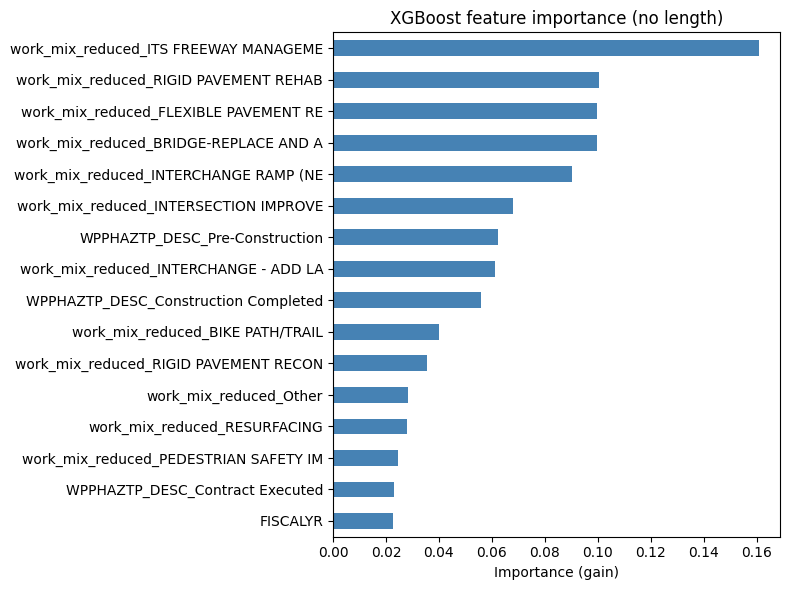

In [11]:
top_n = min(16, len(feat_imp))
ax = feat_imp.head(top_n).iloc[::-1].plot(kind="barh", figsize=(8, 6), color="steelblue")
ax.set_xlabel("Importance (gain)")
ax.set_title("XGBoost feature importance (no length)")
plt.tight_layout()
plt.show()


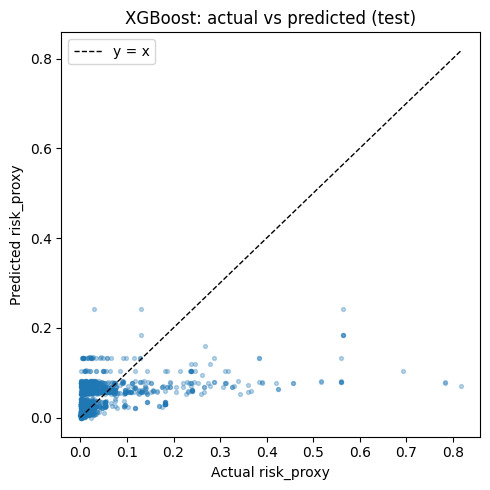

In [12]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.3, s=8)
mx = float(max(y_test.max(), y_pred.max()))
plt.plot([0, mx], [0, mx], "k--", lw=1, label="y = x")
plt.xlabel("Actual risk_proxy")
plt.ylabel("Predicted risk_proxy")
plt.title("XGBoost: actual vs predicted (test)")
plt.legend()
plt.tight_layout()
plt.show()


### Results

- The XGBoost model demonstrated only a marginal improvement over the Random Forest baseline without length, increasing $R^2$ from ~0.14 to ~0.15.
- This confirms that model choice has limited impact on predictive performance when key explanatory variables (segment length) are excluded.
- The low $R^2$ cross both models indicates that categorical features (phase and work mix) provide only weak explanatory power for the engineered risk proxy.

### Conclusion

- The comparison between models demonstrates that predictive performance is fundamentally constrained by the available features, rather than model complexity.
- Segment length is the primary driver of the engineered risk proxy, and without it, both Random Forest and XGBoost models fail to capture sufficient variance.
- This reinforces that the current dataset is better suited for descriptive ranking rather than predictive modeling. 